<a href="https://colab.research.google.com/github/Alhmmada/Bike-Sharing-Demand-Prediction/blob/main/Assignment%203%20CLUSTERING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import io
from google.colab import files

uploaded = files.upload()

Saving dataset_exercise_5_clustering_highway_traffic (1).csv to dataset_exercise_5_clustering_highway_traffic (1).csv
Saving evaluation_dataset_exercise_5_clustering_highway_traffic.csv to evaluation_dataset_exercise_5_clustering_highway_traffic.csv


In [3]:
filename = next(iter(uploaded))
data_df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=";")

print("Inläst fil:", filename)
print("Antal rader och kolumner:", data_df.shape)

data_df.head()

Inläst fil: dataset_exercise_5_clustering_highway_traffic (1).csv
Antal rader och kolumner: (104843, 7)


,PORTAL,Date,time_from,time_to,Interval_5,SPEED_MS_AVG,flow
0,"E4S 56,780",20210101,00:00:00,00:05:00,0,18.56,39
1,"E4S 56,780",20210101,00:05:00,00:10:00,1,20.39,18
2,"E4S 56,780",20210101,00:10:00,00:15:00,2,19.27,26
3,"E4S 56,780",20210101,00:15:00,00:20:00,3,19.52,52
4,"E4S 56,780",20210101,00:20:00,00:25:00,4,20.52,52


In [4]:
# Spara utvärderingsdata till senare
evaluation_df = data_df.copy()

# Ladda upp träningsfilen
uploaded_train = files.upload()
train_filename = next(iter(uploaded_train))

data_df = pd.read_csv(
    io.BytesIO(uploaded_train[train_filename]),
    sep=";"
)

print("Träningsfil:", train_filename)
print("Antal rader och kolumner:", data_df.shape)
data_df.head()


Saving dataset_exercise_5_clustering_highway_traffic (1).csv to dataset_exercise_5_clustering_highway_traffic (1) (1).csv
Träningsfil: dataset_exercise_5_clustering_highway_traffic (1) (1).csv
Antal rader och kolumner: (104843, 7)


,PORTAL,Date,time_from,time_to,Interval_5,SPEED_MS_AVG,flow
0,"E4S 56,780",20210101,00:00:00,00:05:00,0,18.56,39
1,"E4S 56,780",20210101,00:05:00,00:10:00,1,20.39,18
2,"E4S 56,780",20210101,00:10:00,00:15:00,2,19.27,26
3,"E4S 56,780",20210101,00:15:00,00:20:00,3,19.52,52
4,"E4S 56,780",20210101,00:20:00,00:25:00,4,20.52,52


In [5]:
# Gör om datum till ett datumformat som Python förstår
data_df["Date"] = pd.to_datetime(
    data_df["Date"].astype(str), format="%Y%m%d"
)

print("Första datum:", data_df["Date"].min())
print("Sista datum:", data_df["Date"].max())
print("Antal unika dagar:", data_df["Date"].nunique())

print("\nSaknade värden per kolumn:")
print(data_df.isna().sum())

Första datum: 2021-01-01 00:00:00
Sista datum: 2021-12-31 00:00:00
Antal unika dagar: 365

Saknade värden per kolumn:
PORTAL          0
Date            0
time_from       0
time_to         0
Interval_5      0
SPEED_MS_AVG    0
flow            0
dtype: int64


In [6]:
# Kontrollera om samma datum och intervall förekommer flera gånger
duplicates = data_df.duplicated(["Date", "Interval_5"]).sum()
print("Dubbletter av datum + intervall:", duplicates)

# Bygg dagsprofiler om varje datum och intervall är unikt
if duplicates == 0:
    day_matrix = data_df.pivot(
        index="Date",
        columns="Interval_5",
        values="flow"
    ).reindex(columns=range(288)).sort_index()

    print("Tabellens storlek:", day_matrix.shape)
    print("Saknade intervall:", day_matrix.isna().sum().sum())
    print("Dagar med saknade intervall:",
          day_matrix.isna().any(axis=1).sum())

    display(day_matrix.head())
else:
    print("Vi behöver undersöka dubbletterna innan vi fortsätter.")

Dubbletter av datum + intervall: 0
Tabellens storlek: (365, 288)
Saknade intervall: 277
Dagar med saknade intervall: 28


Interval_5,0,1,2,3,4,5,6,7,8,9,...,278,279,280,281,282,283,284,285,286,287
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,39.0,18.0,26.0,52.0,52.0,74.0,68.0,109.0,91.0,121.0,...,52.0,67.0,57.0,40.0,43.0,42.0,43.0,32.0,39.0,34.0
2021-01-02,30.0,32.0,27.0,37.0,37.0,23.0,39.0,32.0,23.0,30.0,...,58.0,71.0,49.0,59.0,68.0,63.0,55.0,44.0,41.0,39.0
2021-01-03,36.0,44.0,52.0,61.0,55.0,57.0,55.0,44.0,38.0,39.0,...,47.0,51.0,43.0,28.0,57.0,43.0,33.0,50.0,45.0,23.0
2021-01-04,41.0,36.0,37.0,31.0,37.0,33.0,31.0,32.0,28.0,23.0,...,54.0,44.0,52.0,27.0,54.0,31.0,35.0,28.0,43.0,18.0
2021-01-05,41.0,32.0,40.0,32.0,33.0,46.0,28.0,24.0,26.0,23.0,...,56.0,69.0,57.0,46.0,49.0,43.0,40.0,56.0,31.0,43.0


In [7]:
# Skapa en separat tabell med bara kompletta dagar
day_matrix_clean = day_matrix.dropna().copy()

print("Dagar före:", len(day_matrix))
print("Dagar efter:", len(day_matrix_clean))
print("Saknade värden:", day_matrix_clean.isna().sum().sum())

Dagar före: 365
Dagar efter: 337
Saknade värden: 0


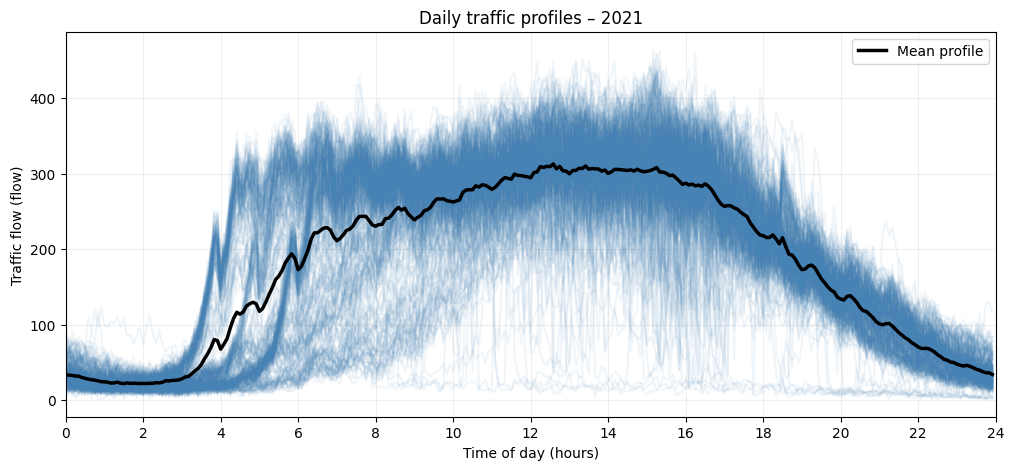

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Omvandla intervallnumren till timmar
hours = np.arange(288) / 12

plt.figure(figsize=(12, 5))

# En blå linje för varje dag
plt.plot(
    hours, day_matrix_clean.T,
    color="steelblue", alpha=0.08
)

# Svart linje visar medelvärdet för de 337 dagarna
plt.plot(
    hours, day_matrix_clean.mean(axis=0),
    color="black", linewidth=2.5, label="Mean profile"
)

plt.xlabel("Time of day (hours)")
plt.ylabel("Traffic flow (flow)")
plt.title("Daily traffic profiles – 2021")
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

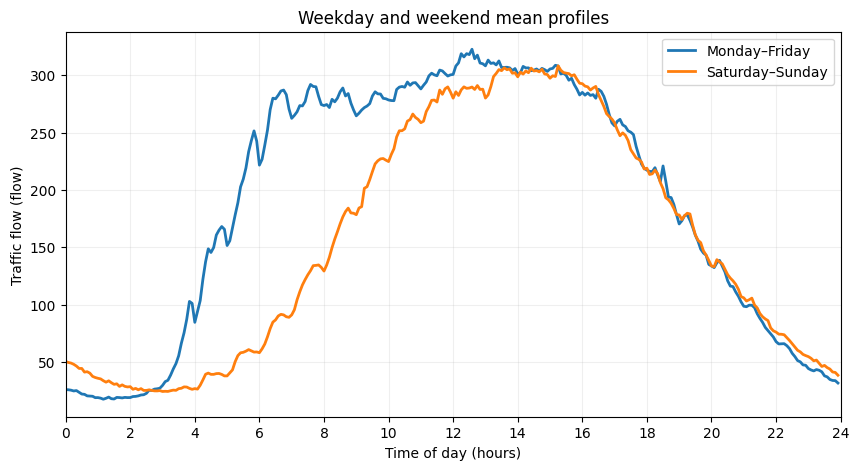

In [9]:
# Monday = 0, Sunday = 6
is_weekday = day_matrix_clean.index.dayofweek < 5

weekday_mean = day_matrix_clean.loc[is_weekday].mean(axis=0)
weekend_mean = day_matrix_clean.loc[~is_weekday].mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(hours, weekday_mean, label="Monday–Friday", linewidth=2)
plt.plot(hours, weekend_mean, label="Saturday–Sunday", linewidth=2)

plt.xlabel("Time of day (hours)")
plt.ylabel("Traffic flow (flow)")
plt.title("Weekday and weekend mean profiles")
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Antal dagar i varje kluster:
0    120
1    134
2     83
Name: count, dtype: int64


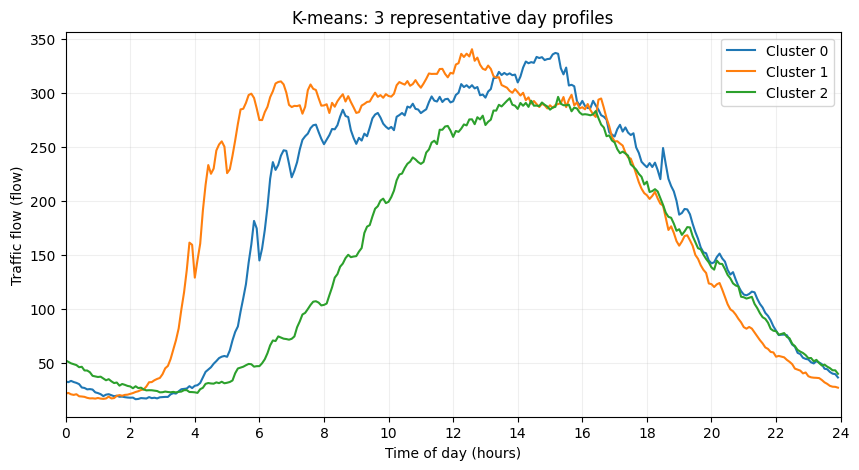

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(day_matrix_clean)

print("Antal dagar i varje kluster:")
print(pd.Series(labels).value_counts().sort_index())

plt.figure(figsize=(10, 5))

for cluster_id, centroid in enumerate(kmeans.cluster_centers_):
    plt.plot(hours, centroid, label=f"Cluster {cluster_id}")

plt.xlabel("Time of day (hours)")
plt.ylabel("Traffic flow (flow)")
plt.title("K-means: 3 representative day profiles")
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [11]:
# Koppla varje dags kluster till dess veckodag
cluster_info = pd.DataFrame({
    "Cluster": labels,
    "Weekday": day_matrix_clean.index.dayofweek
}, index=day_matrix_clean.index)

# Räkna dagar per kluster och veckodag
weekday_table = pd.crosstab(
    cluster_info["Cluster"],
    cluster_info["Weekday"]
).reindex(columns=range(7), fill_value=0)

weekday_table.columns = [
    "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"
]

display(weekday_table)

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Cluster,,,,,,,
0,14,20,19,22,19,18,8
1,30,26,25,27,26,0,0
2,2,0,1,0,5,34,41


In [12]:
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    test_labels = model.fit_predict(day_matrix_clean)
    score = silhouette_score(day_matrix_clean, test_labels)

    results.append({
        "Clusters": k,
        "Silhouette": score
    })

k_results = pd.DataFrame(results)
display(k_results.round(3))

,Clusters,Silhouette
0,2,0.308
1,3,0.269
2,4,0.267
3,5,0.271
4,6,0.237
5,7,0.232
6,8,0.229
7,9,0.203
8,10,0.192


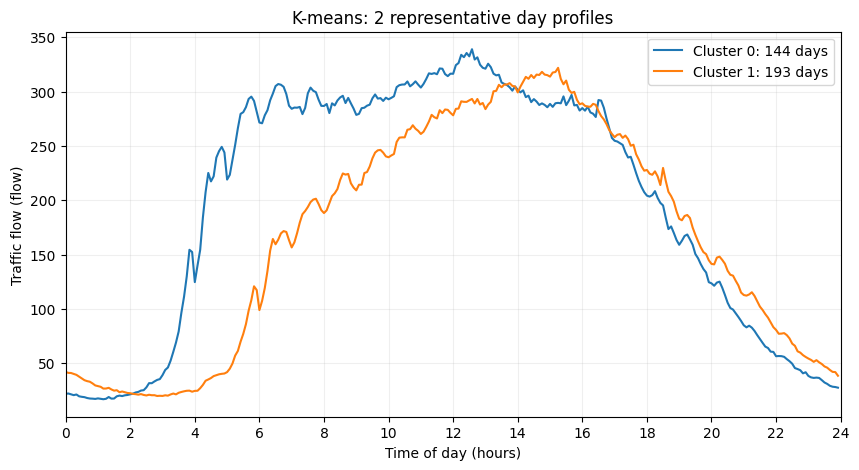

In [13]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_2 = kmeans_2.fit_predict(day_matrix_clean)

plt.figure(figsize=(10, 5))

for cluster_id, centroid in enumerate(kmeans_2.cluster_centers_):
    count = (labels_2 == cluster_id).sum()
    plt.plot(
        hours, centroid,
        label=f"Cluster {cluster_id}: {count} days"
    )

plt.xlabel("Time of day (hours)")
plt.ylabel("Traffic flow (flow)")
plt.title("K-means: 2 representative day profiles")
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [14]:
from sklearn.cluster import AgglomerativeClustering

agg_results = []

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    agg_labels = model.fit_predict(day_matrix_clean)

    agg_results.append({
        "Clusters": k,
        "Agglomerative": silhouette_score(
            day_matrix_clean, agg_labels
        )
    })

comparison = k_results.rename(
    columns={"Silhouette": "KMeans"}
).merge(pd.DataFrame(agg_results), on="Clusters")

display(comparison.round(3))

,Clusters,KMeans,Agglomerative
0,2,0.308,0.291
1,3,0.269,0.268
2,4,0.267,0.258
3,5,0.271,0.264
4,6,0.237,0.250
5,7,0.232,0.243
6,8,0.229,0.240
7,9,0.203,0.233
8,10,0.192,0.215


In [15]:
from sklearn.mixture import GaussianMixture

gmm_results = []

for k in range(2, 11):
    model = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        n_init=5,
        random_state=42,
        max_iter=300
    )

    gmm_labels = model.fit_predict(day_matrix_clean)

    gmm_results.append({
        "Clusters": k,
        "GMM": silhouette_score(day_matrix_clean, gmm_labels),
        "Converged": model.converged_
    })

gmm_results = pd.DataFrame(gmm_results)

comparison_gmm = comparison.merge(gmm_results, on="Clusters")
display(comparison_gmm.round(3))

,Clusters,KMeans,Agglomerative,GMM,Converged
0,2,0.308,0.291,0.306,True
1,3,0.269,0.268,0.261,True
2,4,0.267,0.258,0.266,True
3,5,0.271,0.264,0.255,True
4,6,0.237,0.250,0.238,True
5,7,0.232,0.243,0.237,True
6,8,0.229,0.240,0.198,True
7,9,0.203,0.233,0.180,True
8,10,0.192,0.215,0.188,True


In [16]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X = day_matrix_clean.to_numpy()
dbscan_results = []

for min_samples in [3, 5, 10]:
    # Hitta avståndet till respektive dags sista nödvändiga granne
    neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X)
    distances, _ = neighbors.kneighbors(X)
    neighbor_distances = distances[:, -1]

    # Välj testvärden för eps utifrån avstånden i våra data
    for quantile in [0.50, 0.70, 0.90]:
        eps = float(np.quantile(neighbor_distances, quantile))

        db_labels = DBSCAN(
            eps=eps,
            min_samples=min_samples
        ).fit_predict(X)

        grouped = db_labels != -1
        n_clusters = len(np.unique(db_labels[grouped]))
        noise_pct = 100 * (~grouped).mean()

        score = np.nan
        if 2 <= n_clusters < grouped.sum():
            score = silhouette_score(
                X[grouped], db_labels[grouped]
            )

        dbscan_results.append({
            "min_samples": min_samples,
            "eps": eps,
            "Clusters": n_clusters,
            "Noise_%": noise_pct,
            "Silhouette": score
        })

dbscan_results = pd.DataFrame(dbscan_results)
display(dbscan_results.round(3))

,min_samples,eps,Clusters,Noise_%,Silhouette
0,3,517.513,4,45.104,0.186
1,3,601.436,2,28.190,0.001
2,3,788.274,1,9.496,NaN
3,5,551.439,2,37.092,0.001
4,5,624.050,2,23.442,-0.014
5,5,835.648,1,6.825,NaN
6,10,596.861,3,31.157,0.215
7,10,682.082,2,16.617,-0.013
8,10,893.126,1,4.154,NaN


In [17]:
from sklearn.metrics import adjusted_rand_score

stability_results = []

for seed in range(10):
    model = KMeans(
        n_clusters=2,
        random_state=seed,
        n_init=10
    )

    new_labels = model.fit_predict(day_matrix_clean)

    stability_results.append({
        "Seed": seed,
        "Silhouette": silhouette_score(
            day_matrix_clean, new_labels
        ),
        "ARI_vs_original": adjusted_rand_score(
            labels_2, new_labels
        )
    })

stability_results = pd.DataFrame(stability_results)
display(stability_results.round(3))

,Seed,Silhouette,ARI_vs_original
0,0,0.308,1.0
1,1,0.308,1.0
2,2,0.308,1.0
3,3,0.308,1.0
4,4,0.308,1.0
5,5,0.308,1.0
6,6,0.308,1.0
7,7,0.308,1.0
8,8,0.308,1.0
9,9,0.308,1.0


In [18]:
cluster_info_2 = pd.DataFrame({
    "Cluster": labels_2,
    "Weekday": day_matrix_clean.index.dayofweek
}, index=day_matrix_clean.index)

weekday_table_2 = pd.crosstab(
    cluster_info_2["Cluster"],
    cluster_info_2["Weekday"]
).reindex(columns=range(7), fill_value=0)

weekday_table_2.columns = [
    "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"
]

display(weekday_table_2)

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Cluster,,,,,,,
0,30,30,27,29,28,0,0
1,16,16,18,20,22,52,49


In [19]:
# Arbeta med en kopia av utvärderingsdata
eval_df = evaluation_df.copy()

eval_df["Date"] = pd.to_datetime(
    eval_df["Date"].astype(str), format="%Y%m%d"
)

print("År i utvärderingsdata:", eval_df["Date"].dt.year.unique())

duplicates_eval = eval_df.duplicated(
    ["Date", "Interval_5"]
).sum()

print("Dubbletter:", duplicates_eval)

if duplicates_eval == 0:
    eval_matrix = eval_df.pivot(
        index="Date",
        columns="Interval_5",
        values="flow"
    ).reindex(columns=range(288)).sort_index()

    eval_matrix_clean = eval_matrix.dropna().copy()

    print("Antal dagar före:", len(eval_matrix))
    print("Saknade intervall:", eval_matrix.isna().sum().sum())
    print("Antal kompletta dagar:", len(eval_matrix_clean))
else:
    print("Vi behöver undersöka dubbletterna först.")

År i utvärderingsdata: [2021]
Dubbletter: 0
Antal dagar före: 365
Saknade intervall: 277
Antal kompletta dagar: 337


In [20]:
centroids = kmeans_2.cluster_centers_
test_days = eval_matrix_clean.to_numpy()

actual = []
cluster_predictions = []
persistence_predictions = []

for day in test_days:
    for t in range(5, 288):
        # Endast observationer före tidpunkten vi förutsäger
        recent = day[t-5:t]
        patterns = centroids[:, t-5:t]

        distances = np.sum((patterns - recent) ** 2, axis=1)
        best_cluster = np.argmin(distances)

        cluster_predictions.append(centroids[best_cluster, t])
        persistence_predictions.append(day[t-1])
        actual.append(day[t])

actual = np.array(actual)

def calculate_errors(predictions):
    errors = np.array(predictions) - actual
    return {
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2))
    }

prediction_results = pd.DataFrame({
    "KMeans_2": calculate_errors(cluster_predictions),
    "Persistence": calculate_errors(persistence_predictions)
}).T

display(prediction_results.round(3))
print("Antal prognoser per metod:", len(actual))

,MAE,RMSE
KMeans_2,28.629,44.401
Persistence,18.260,26.838


Antal prognoser per metod: 95371


In [21]:
# En gemensam medelprofil från träningsdata
mean_profile = day_matrix_clean.mean(axis=0).to_numpy()

# Samma dagar och tidpunkter som i föregående test
mean_predictions = np.tile(
    mean_profile[5:],
    len(test_days)
)

prediction_results.loc["Historical_mean"] = calculate_errors(
    mean_predictions
)

display(prediction_results.round(3))

,MAE,RMSE
KMeans_2,28.629,44.401
Persistence,18.260,26.838
Historical_mean,42.923,61.397


In [22]:
month_table = pd.crosstab(
    cluster_info_2.index.month,
    cluster_info_2["Cluster"]
).reindex(index=range(1, 13), fill_value=0)

month_table.index.name = "Month"

# Andel av månadens kompletta dagar i respektive kluster
month_percent = month_table.div(
    month_table.sum(axis=1), axis=0
) * 100

display(month_percent.round(1))

Cluster,0,1
Month,,
1,0.0,100.0
2,0.0,100.0
3,0.0,100.0
4,0.0,100.0
5,60.7,39.3
6,70.0,30.0
7,61.5,38.5
8,70.0,30.0
9,70.8,29.2


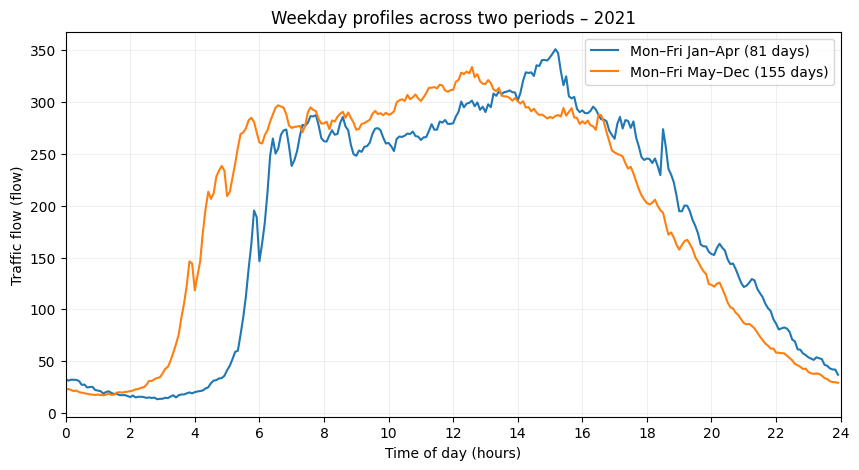

In [23]:
weekday_mask = day_matrix_clean.index.dayofweek < 5
early_mask = day_matrix_clean.index.month <= 4

early_weekdays = day_matrix_clean.loc[
    weekday_mask & early_mask
]

later_weekdays = day_matrix_clean.loc[
    weekday_mask & ~early_mask
]

plt.figure(figsize=(10, 5))

plt.plot(
    hours, early_weekdays.mean(axis=0),
    label=f"Mon–Fri Jan–Apr ({len(early_weekdays)} days)"
)

plt.plot(
    hours, later_weekdays.mean(axis=0),
    label=f"Mon–Fri May–Dec ({len(later_weekdays)} days)"
)

plt.xlabel("Time of day (hours)")
plt.ylabel("Traffic flow (flow)")
plt.title("Weekday profiles across two periods – 2021")
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [24]:
summary_rows = []

for method in ["KMeans", "Agglomerative", "GMM"]:
    best_row = comparison_gmm.loc[
        comparison_gmm[method].idxmax()
    ]

    summary_rows.append({
        "Method": method,
        "Best_k": int(best_row["Clusters"]),
        "Silhouette": best_row[method]
    })

method_summary = pd.DataFrame(summary_rows)
display(method_summary.round(3))

,Method,Best_k,Silhouette
0,KMeans,2,0.308
1,Agglomerative,2,0.291
2,GMM,2,0.306


In [25]:
def evaluate_centroids(centroids, test_days):
    predictions = []
    actual_values = []

    for day in test_days:
        for t in range(5, 288):
            recent = day[t-5:t]
            patterns = centroids[:, t-5:t]

            distances = np.sum((patterns - recent) ** 2, axis=1)
            best_cluster = np.argmin(distances)

            predictions.append(centroids[best_cluster, t])
            actual_values.append(day[t])

    errors = np.array(predictions) - np.array(actual_values)

    return {
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2))
    }


external_results = []
test_days = eval_matrix_clean.to_numpy()

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(day_matrix_clean)

    scores = evaluate_centroids(
        model.cluster_centers_, test_days
    )

    external_results.append({
        "Method": "KMeans",
        "Clusters": k,
        **scores
    })

display(pd.DataFrame(external_results).round(3))

,Method,Clusters,MAE,RMSE
0,KMeans,2,28.629,44.401
1,KMeans,3,24.759,38.438
2,KMeans,4,22.689,36.091
3,KMeans,5,21.522,33.002
4,KMeans,6,20.341,31.570
5,KMeans,7,19.579,30.360
6,KMeans,8,19.026,29.676
7,KMeans,9,18.576,28.854
8,KMeans,10,18.280,28.221


In [26]:
print("Träningsmatris:", day_matrix_clean.shape)
print("Utvärderingsmatris:", eval_matrix_clean.shape)

print("Träningsår:",
      sorted(set(day_matrix_clean.index.year)))
print("Utvärderingsår:",
      sorted(set(eval_matrix_clean.index.year)))

print("\nTidigare tvåklustermodell:")
print("Inställningar:", {
    key: kmeans_2.get_params()[key]
    for key in ["n_clusters", "random_state", "n_init"]
})

print("Prognosfel:", evaluate_centroids(
    kmeans_2.cluster_centers_,
    eval_matrix_clean.to_numpy()
))

Träningsmatris: (337, 288)
Utvärderingsmatris: (337, 288)
Träningsår: [2021]
Utvärderingsår: [2021]

Tidigare tvåklustermodell:
Inställningar: {'n_clusters': 2, 'random_state': 42, 'n_init': 10}
Prognosfel: {'MAE': np.float64(28.628964969799156), 'RMSE': np.float64(44.40100866758324)}


In [27]:
import io
from google.colab import files

uploaded_eval = files.upload()

if len(uploaded_eval) != 1:
    raise ValueError("Välj endast utvärderingsfilen.")

eval_filename = next(iter(uploaded_eval))
evaluation_df = pd.read_csv(
    io.BytesIO(uploaded_eval[eval_filename]), sep=";"
)

evaluation_df["Date"] = pd.to_datetime(
    evaluation_df["Date"].astype(str), format="%Y%m%d"
)

assert evaluation_df["Date"].dt.year.eq(2022).all(), \
    "Fel fil: utvärderingsdata måste vara från 2022."

assert not evaluation_df.duplicated(["Date", "Interval_5"]).any(), \
    "Filen innehåller dubbla datum–intervall."

eval_matrix = evaluation_df.pivot(
    index="Date",
    columns="Interval_5",
    values="flow"
).reindex(columns=range(288)).sort_index()

eval_matrix_clean = eval_matrix.dropna().copy()
test_days = eval_matrix_clean.to_numpy()

print("Utvärderingsår:", eval_matrix_clean.index.year.unique())
print("Kompletta dagar och intervall:", eval_matrix_clean.shape)

Saving evaluation_dataset_exercise_5_clustering_highway_traffic.csv to evaluation_dataset_exercise_5_clustering_highway_traffic (1).csv
Utvärderingsår: Index([2022], dtype='int32', name='Date')
Kompletta dagar och intervall: (69, 288)


In [28]:
external_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(day_matrix_clean)  # Träna på 2021

    scores = evaluate_centroids(
        model.cluster_centers_,
        eval_matrix_clean.to_numpy()  # Utvärdera på 2022
    )

    external_results.append({
        "Method": "KMeans",
        "Clusters": k,
        **scores
    })

display(pd.DataFrame(external_results).round(3))

,Method,Clusters,MAE,RMSE
0,KMeans,2,27.791,43.395
1,KMeans,3,25.184,39.583
2,KMeans,4,23.840,37.729
3,KMeans,5,22.224,32.953
4,KMeans,6,20.640,31.076
5,KMeans,7,19.886,30.026
6,KMeans,8,19.294,29.334
7,KMeans,9,19.281,28.950
8,KMeans,10,18.967,28.292


In [29]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

X_train = day_matrix_clean.to_numpy()
X_eval = eval_matrix_clean.to_numpy()

# Behåll K-means-resultaten och undvik dubbla rader vid omkörning
external_results = [
    row for row in external_results
    if row["Method"] == "KMeans"
]

for method in ["Agglomerative", "GMM"]:
    for k in range(2, 11):

        if method == "Agglomerative":
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage="ward"
            )
        else:
            model = GaussianMixture(
                n_components=k,
                covariance_type="diag",
                n_init=5,
                random_state=42,
                max_iter=300
            )

        train_labels = model.fit_predict(X_train)

        # Medelprofil för varje grupp, endast från 2021
        centroids = np.vstack([
            X_train[train_labels == group].mean(axis=0)
            for group in np.unique(train_labels)
        ])

        scores = evaluate_centroids(centroids, X_eval)

        external_results.append({
            "Method": method,
            "Clusters": k,
            **scores
        })

external_table = pd.DataFrame(external_results)

display(
    external_table[
        external_table["Method"] != "KMeans"
    ].round(3)
)

,Method,Clusters,MAE,RMSE
9,Agglomerative,2,27.995,43.781
10,Agglomerative,3,25.708,39.950
11,Agglomerative,4,23.983,37.652
12,Agglomerative,5,22.659,33.456
13,Agglomerative,6,21.088,31.692
14,Agglomerative,7,20.146,30.496
15,Agglomerative,8,20.131,30.606
16,Agglomerative,9,19.710,29.520
17,Agglomerative,10,19.473,29.263
18,GMM,2,27.829,43.402


In [30]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

dbscan_external_results = []

for min_samples in [3, 5, 10]:
    neighbors = NearestNeighbors(
        n_neighbors=min_samples
    ).fit(X_train)

    distances, _ = neighbors.kneighbors(X_train)
    neighbor_distances = distances[:, -1]

    for quantile in [0.50, 0.70, 0.90]:
        eps = float(np.quantile(neighbor_distances, quantile))

        train_labels = DBSCAN(
            eps=eps,
            min_samples=min_samples
        ).fit_predict(X_train)

        groups = np.unique(train_labels[train_labels != -1])
        scores = {"MAE": np.nan, "RMSE": np.nan}

        if len(groups) > 0:
            centroids = np.vstack([
                X_train[train_labels == group].mean(axis=0)
                for group in groups
            ])

            scores = evaluate_centroids(centroids, X_eval)

        dbscan_external_results.append({
            "min_samples": min_samples,
            "eps": eps,
            "Clusters": len(groups),
            "Training_noise_%": 100 * (train_labels == -1).mean(),
            **scores
        })

dbscan_external_table = pd.DataFrame(dbscan_external_results)
display(dbscan_external_table.round(3))

,min_samples,eps,Clusters,Training_noise_%,MAE,RMSE
0,3,517.513,4,45.104,26.567,41.939
1,3,601.436,2,28.190,33.244,51.524
2,3,788.274,1,9.496,42.358,61.627
3,5,551.439,2,37.092,33.797,52.232
4,5,624.050,2,23.442,33.383,51.721
5,5,835.648,1,6.825,42.253,61.418
6,10,596.861,3,31.157,25.429,41.264
7,10,682.082,2,16.617,33.349,51.939
8,10,893.126,1,4.154,42.175,61.267
